# How to Choose One Card By Analyzing Every Draft Ever


Welcome to my new platform dedicated to limited analytics! In this article we're going to find out what happens when you use metrics to pick cards. Thanks to 17Lands [public data sets](https://www.17lands.com/public_datasets), we have a resource of 2.27 million drafts with all the data we need to answer this question comprehensively. For one pick, anyway. So no, not every draft ever, but we would if we could. I'll show you a chart with the broad results, and then we'll go deep on the analysis behind it.

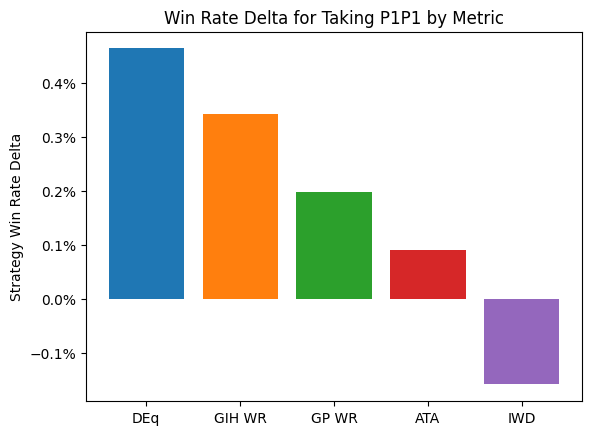

In [1]:
from deq.p1_strategy import all_metrics_analysis
from deq.plot import p1_delta_bar
result = all_metrics_analysis()
p1_delta_bar(result)

So here's the claim: if you use [DEq](https://docs.google.com/spreadsheets/d/1n1pfrb5q_2ICYk-vfF3Uwo8t61DJU-5T_DFe0dwk8DY/edit?usp=sharing) to choose your first card, and then carry on doing everything else just the way you would currently do it, on average you will pick up 0.46% in win rate. I think it's reasonable to hope good things might happen if you keep using it intelligently past one pick, but we're not going to get there using statistics, not today anyway. But almost half a point for making one pick differently? That's pretty good, I think. Worth sticking around to find out more. 

Now, this isn't just "people did this much better when they followed such and such strategy." That's an interesting thing to look at, but if you want to infer causality, there is a serious problem with selection bias. The most powerful cards are also the easiest
to slam into your pile, so when people *didn't* pick the number one card by some metric, there's a greater than average chance that the overall pack quality might not have been so hot in the first place. Even if we're comparing two metrics, one metric might suggest mediocre picks that would bring down the result, and another might suggest downright awful picks that no one even tried in practice. So what we need to do is understand what would happen if *every* pick was made using a given metric, by looking at representative real-world results, and that's what we did, while controlling for the most important covariate, player skill.

For every draft over the last 16 major formats, we identify the highest ranked card according to each metric, as calculated using the top player data for the whole format, then go find the average result for events where that card was chosen first, by a player of similar skill, and substitute the result. 

Besides controlling for bias, the player skill estimate is of independent interest. We might expect the size of the improvement to decrease as player skill increases, and it does, so it's important to know the exact shape of this decrease so that we can apply it to our own skill level. Thanks to our large data set, we can finely slice the player base to obtain estimates across the full range of player skill. Let's look at the chart above broken out by my estimate of player skill:


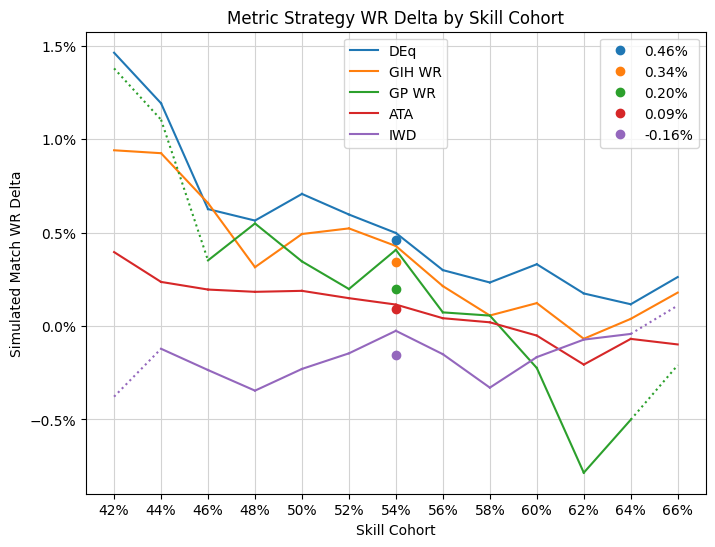

In [2]:
from deq.plot import p1_line_plot
p1_line_plot(result)

The dots aligned above the 54% cohort represent the average increase in winrate aggregated across all of the cohorts, the same data presented in the bar plot above. The lines chart the estimated change in win rate for each skill cohort. The values are calculated almost entirely independently, 
so any smoothness can be attributed to a fundamental relationship between card choice and excess victory identified by the metric. For every cohort from 48% to 66%, choosing pick one by DEq delivers the best result, and a substantial increase over the baseline results. Some of the other metrics are pretty good too! GIH WR especially, which won't be a surprise to most of you but frankly I did not predict, as I've been fairly critical of its flaws as a metric over the past few months and perhaps have failed to appreciate its virtues. That said, there's no clear benefit to moving to picking by GIH WR for players above 56% in win rate from what they're already doing.

So there you have it, if you're inclined to trust me: a first-ever look at the effect of truly relying on a card quality metric to make decisions. Most players would do very well to hop onto 17Lands a little more often and trust some of your decisions what you find there (unless it's IWD, don't use that!). Everyone, including the highly competitive all the way up to the true elite, would benefit from following DEq, that is, from taking the information from ATA and GP% as necessary corrections to GP WR, and taking the combined value as a measurement of card quality.

Questions? I hope so, because I have a lot I'd like to share with you and it will be less awkward if you stick around to read it. There are more cool and useful graphs below, I promise. There's even *entropy*!

## Entropy

We'll start with entropy because I think the calculation is actually relevant to the interpretation and application of the results. You might think I'm asking you to make some big change --  after all, you're comfortable using GIH WR to judge card quality, and as the chart indicates, that works pretty well. So, on the strength of an analysis about changing one pick and doing everything else the same, are you supposed to change your evaluations to something unfamiliar? Well no, because you're already picking using DEq, just not as much as you should be. Let me explain.

One of my concerns in performing this analysis was how well the simulated picks represent actual player behavior. The more representative the results, the more reliable they should be. We'll look at a concrete example of the problem. Exactly one person first-picked Failed Fording over the entire OTJ public data set, yet it was the highest-ranked card by GIH WR 800 times (in one of my test runs at least). What do we do with those 800 drafts? Well, for the cohort where the player that picked it happened to live, I used the result, scaled up for however many drafts needed it. For the neighboring cohorts, I look around for results I can borrow and adjust for the skill differential. And for the distant cohorts, I just used the baseline win rate adjusted down by the estimated value of a first pick, guessing that if a pick is so unremarkable that no one ever bothered trying it, it probably didn't add more than negligible value as a first pick. An extra Failed Fording is not typically going to make our break your draft.

For all of these cases, it might be the most reasonable approach to get a usable value. It's still just one marginal card and sample size can win out in the end, but I needed to keep track of this kind of degradation of the sample space. Beyond a certain point we should be careful relying on the results. The case where a small number of drafts are blown up to represent many more is a kind of loss of information. Even though we might have approximately the same *number* of samples in our calculation (leaving out picked cards that were literally never top-ranked by the metric), the more relative weight a small number of those samples have, the less of the information in the sample space is available to our estimates.

Now, it may seem abstract to try to measure that, but there's actually a standard: *entropy*. Entropy will measure the information content of a sample with a logarithmic scale. We'll scale it so that we're looking at *bits* of entropy, that is, an entropy value of 20 will represent an unweighted sample space with $2^{20}$ or about a million samples. When we transform the sample space to simulate a metric-based strategy, the amount of entropy will necessarily decrease based on the amount of distortion. Additionally, if we use substitute values from neighboring cohorts or a fallback number, I will ignore the entropy from those sources, since I'm interested in how the information of the representative cohort is preserved, Let's take a look at the "Representative Entropy" chart.

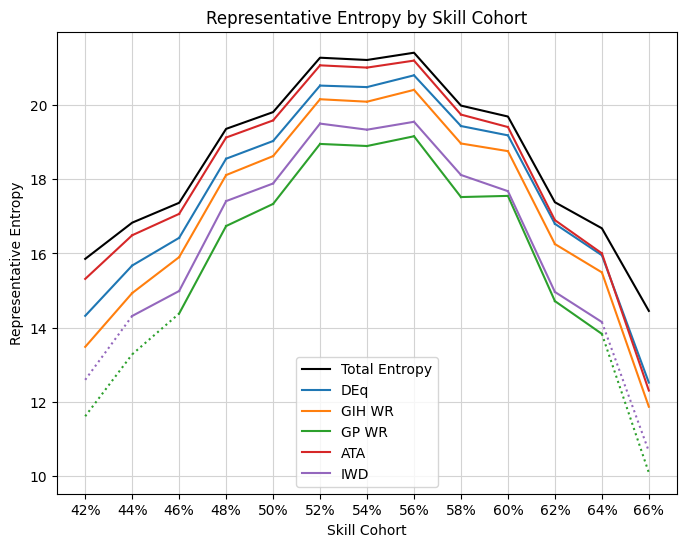

In [3]:
p1_line_plot(result, mode="entropy")

This graph contains information about the total sample size for each cohort, as well as how each metric affects the information space. 
First check out the 54% cohort. The "total" entropy is about 21.2, which represents $2^{21.2}$ 
or about 2.4 
million games, which is indeed the number observed
for that cohort. For the 66% cohort, the value is a bit above 14, which corresponds to about 22,000 matches. Looking at the curves for the metric strategies
, the first thing to note is that the general shape matches what we should 
expect -- they generally reproduce the underlying sample space, so they should have the same order of magnitude of information, but 
with some degradation. This is a nice sanity check that we're doing something sensible with both the reweighting and the entropy calculation. Notably the elements that constitute the model entropy can have either positive or negative sign depending on the direction of scale, so the strict inequality is enforced only by the theoretical relationship, which is a cool effect to observe.

Now lets look at some of the particular curves. In order to do that it will be more convenient to set the total as a baseline and see how much of that entropy is lost in the transformation. So the next graph simply subtracts off the "total" line. The overall sample size is important, but I'm mostly interested in how the metric strategies reflect the underlying behavior.

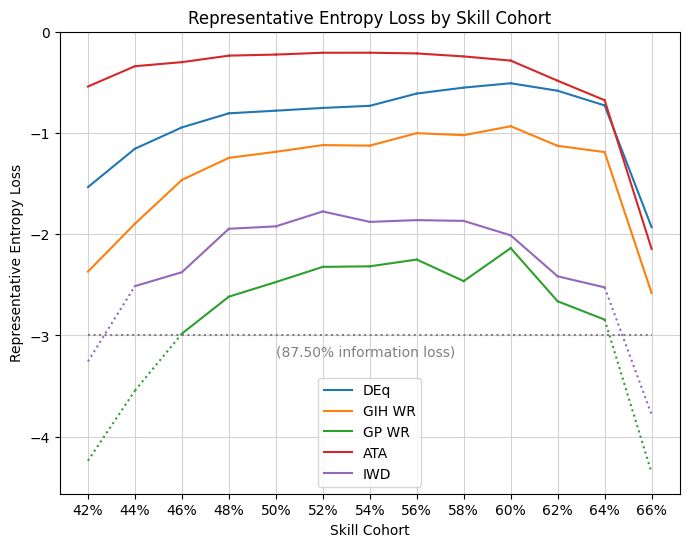

In [5]:
p1_line_plot(result, mode='entropy_loss')

The metric retaining the most entropy is ATA. This makes sense. ATA describes the way that people draft, so a strategy based on ATA should
have the most general similarity to aggregate player behavior. So far so good. Next up is DEq. Not only does DEq perform the best in the win rate analysis, but it also gives a reasonable representation of player behavior. Furthermore, there's a trend to the shape that suggests that it is at its strongest in
modeling elite player behavior -- its maximum is in the 60% cohort, which actually consists of player's whose average win rate was about 63%, due to the skill estimation. The consistently narrowing shape from the worst- to the best-performing cohorts tells a 
compelling story (to me anyway). In fact, for the top cohort, DEq does a better job than ATA at mimicking the actual strategy used. 

The remaining metrics have a well-established hierarchy from there. GIH WR (notably also peaking for the 60% cohort), IWD, then GP WR, with the latter two metrics barely capturing a meaningful portion of player picks. I added a dotted line to indicate what I consider to be an unacceptable loss of representative quality, and which also applies to the win rate graph. Above -2 or so, even though 75% of the "information" may be lost, a very large majority of the substitute data is still coming from a large number of real games played by the cohort under analysis. I consider this data to be fairly reliable, at least for the cohorts with large sample sizes to begin with. Below -3, you start to get 5-10% or more of results being calculated by some kind of data substitution and correction, which might be fine, but might also not be fine, so I'd be hesitant to rely on that. For instance, that big uptick for GP WR at 64% and 66%, I'm doubtful there's any meaningful interpretation of that beyond variance.

So this is what I meant by "you're already using DEq". What the average player is really doing, on average anyway, is described by ATA. But among the win rate metrics ([it is one](deq)), DEq most closely models player behavior. Well sure, it uses ATA. But take that versimillitude, and combine it with the fact that DEq handily wins the win rate analysis across nearly every cohort, and I think that paints a compelling picture of a useful metric. 

## Reproducible Strategies

Now, there's a major hole in this scheme. You can't make picks based on what metrics look like at the end of the format; you have to work with what you've got at the time. Now, I think there's value in a retrospective evaluation of card quality, and the most straightforward thing to do is to use all of the data first, so that's what I did.

Nevertheless we need to look at reproducible strategies, that is, something you could actually implement in practice. We have two passes through the data. First, the filter we use to 
calculate the metrics, and second, the set of drafts that we compare using the substitution analysis. The second set must necessarily be as large as is practical, because we saw representation issues even when using the full data set, but the first filter can represent whatever we would use in practice. So let's start with the day one metrics. That first rush we get when the 17Lands card data page fills up with numbers on that first Wednesday morning. We will use those rankings, and take the first 12 days of the format as our substitution set. Here are the results of that analysis:

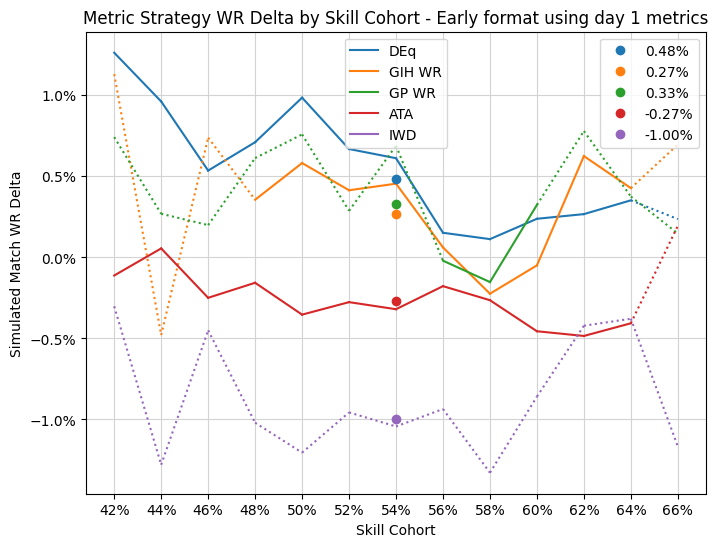

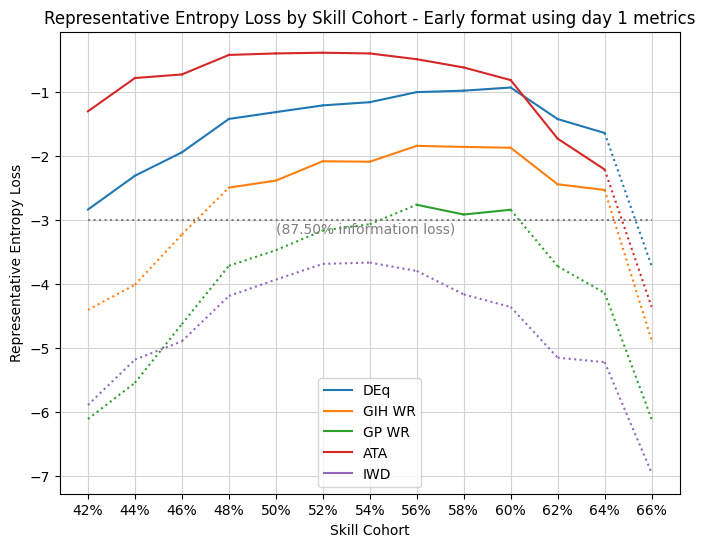

In [21]:
early_format = {'lhs': 'format_day', 'op': '<', 'rhs': 13}
res_d1 = all_metrics_analysis(
    metric_filter={'format_day': 1},
    results_filter=early_format
)
tag_d1 = "Early format using day 1 metrics"
p1_line_plot(res_d1, mode='wr_delta', title_extra=tag_d1)
p1_line_plot(res_d1, mode='entropy_loss', title_extra=tag_d1)

To me, this was the most surprising and gratifying result of the bunch. Again, DEq comes out on top, providing 0.48% of win rate on average across the entire data set (this time, just over a million drafts). This is from changing a single pick, and from continuing to use the day one cut for 12 days of the format! The thing that really shocked me was the gap between DEq and ATA. DEq is effectively a combination of ATA and GP WR, so for ATA to perform so poorly but this not to affect the quality of the result was a relief. I honestly had no clue how ATA or the win rate metrics would perform, so it was exciting to see a result as clear as this. The results make sense intuitively as well (though that didn't make them predictable, for me anyway). The metric is drawn from the whole player base on day 1, and ATA measures the player base's knowledge of the format -- which is nil, in this case. So it's intuitive that relying on that knowledge to make picks is a bad idea.

Additionally, we see GP WR outperform GIH WR, in terms of win rate at least. While I didn't predict it, it's another intuitive result since early days of the format are all about identifying the most powerful decks and exploiting them. GP WR is the stat that will help you do that (aside from DEq, of course). We see an interesting spike for GP WR and GIH WR around 60%-62%, which could be notable, but overall we can tell the halved sample size is already taking its toll on the quality of the analysis, especially when we take a look at the entropy loss. GP WR might be pointing us towards exploitable decks, but it also seems to be recommending plenty of unpalatable choices, to the eyes of our human drafters anyway. DEq again gives the most solid representative picks, especially for the elite cohorts. In fact, for this sample we see a new effect, which is that DEq clearly overtakes ATA in terms of modeling the behavior of elite drafters. They know not to draft like the average person drafted on day one, unsuprisingly. It's also notable that GIH WR has the same general shape as DEq, although it fails to overtake ATA.

Overall, I think this is a clear call to value those early day's returns highly, and to use DEq to interpret them. Given that in practice we get to update our metrics every day, there is apparently a lot of juice to squeeze for more wins in the early format.

Next up, we'll evaluate the late format using metrics from the early format. This transition period to the stable metagame can be especially difficult for those of us relying on metrics, which can still be pointing to archetypes which have had the life squeezed out of them. We'll rely on top players only once again, now that we have more data to work with. Let's take a look.

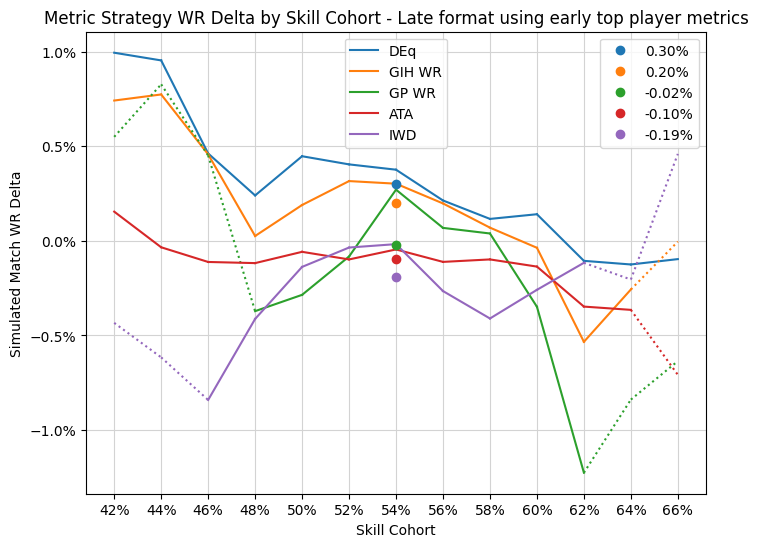

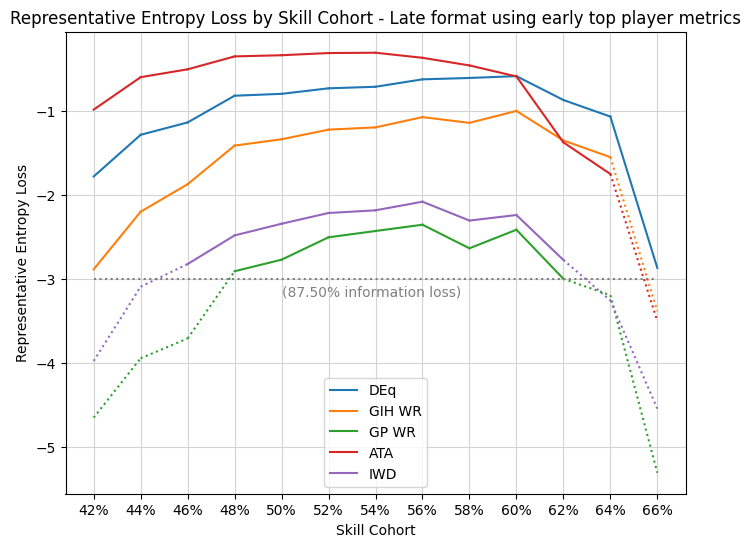

In [23]:
early_top = {'$and': [{'player_cohort': 'Top'}, early_format]}
late_format = {'$not': early_format}
tag_mid = 'Late format using early top player metrics'
res_mid = all_metrics_analysis(metric_filter=early_top, results_filter=late_format)
p1_line_plot(res_mid, mode='wr_delta', title_extra=tag_mid)
p1_line_plot(res_mid, mode='entropy_loss', title_extra=tag_mid)

Things have gotten notably more difficult. DEq, our best performing metric, only gives us 0.3% of win rate if we continue to rely on early format returns throughout the late format. GIH WR stands out from the other 17Lands metrics in this particular cut. The heuristic that it provides a measurement of a card's individual "impact" seems to explain that effect. Unlike the early format, we can't rely on knowing which are the outperforming decks, and that game data has unique value. More than anything else, this chart motivates me to want to integrate the game data into my model at some point in the future. On the other hand, the spike at 62% from the previous analysis has completely reversed, so I chalk that up to noise. I'd suggest looking at both metrics during this transition phase of the format, although I can't say how to combine that information effectively. We continue to see the same behavior in the entropy metric, with DEq being the standout for elite players, but GIH WR predicting behavior better than ATA as well at the top end. It looks like elite players really distinguish themselves in this phase by moving on from the established pick orders using evidence from experience or win rates.

Also notable is that for the first time, no metrics provide a reliable increase in win rate to elite players under the model. As the format is progressing into its mature phase, it is up to you to adjust to the metagame correctly if you want to be in the upper echelon of players. One thing I'm very interesting in looking at down the road is how to detect that card quality signal correctly from the available data during that intermediate phase.

Finally, let's look at applying the mature metrics during the late format. 

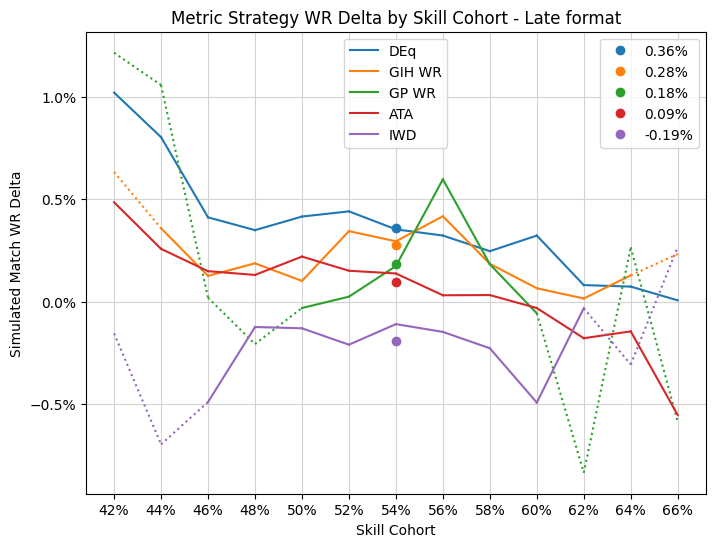

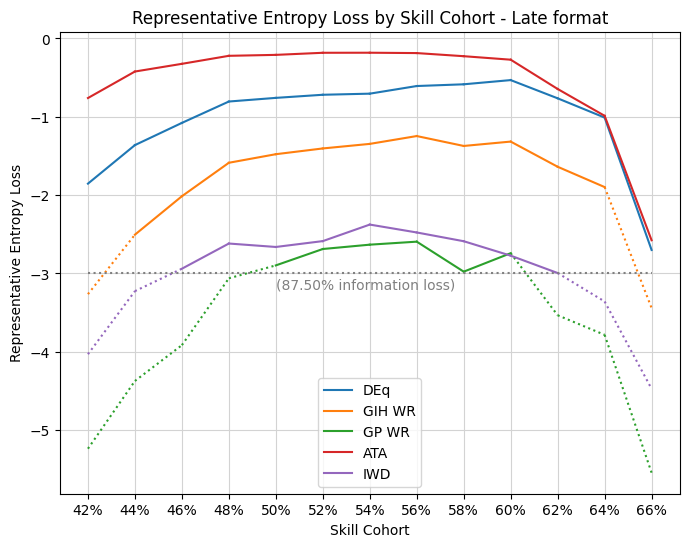

In [18]:
tag_late = 'Late format'
late_top = {'$and': [{'player_cohort': 'Top'}, late_format]}
res_late = all_metrics_analysis(metric_filter=late_top, results_filter=late_format)
p1_line_plot(res_late, mode='wr_delta', title_extra=tag_late)
p1_line_plot(res_late, mode='entropy_loss', title_extra=tag_late)

DEq performs best again, but by the narrowest margin yet. GIH WR provides durable information, and ATA and GP WR recover somewhat in their usefulness, since the metric reflects the actual metagame, as well as the end-format knowledge of the player base. But overall, the pattern established in the previous analyses continues. DEq is the standout metric for card quality in all phases of the format. The others wax and wane in usefulness, with GIH WR being the most reliable of those, especially as the metagame changes.

## Methodology

OK, we've covered the results. I hope they strike you as compelling. But hopefully you have quesitons, because I certainly haven't provided enough detail to assess my methodology. I'll try to cover everything qualitatively now, only leaving out the mathematical and implementation details for a later post.

First, we calculate the value of each metric for each card in each set, using the methodologies described [here](https://www.17lands.com/metrics_definitions), except for DEq, which is described in detail [here](deq). I use the bias adjustment but not the metagame adjustment, as described in that write-up, for this analysis. The set of results used to calculate the metric is described in each post, but I should mention the "Top" player filter that I like to use. Since 17Lands's top filter cohort is out-of-sample, it is not available to analysis of the public data sets, and I have to use an in-sample version as a proxy. "Top" players are defined as those with 100 or more games played and a 58% or greater win rate, according to the data points mentioned below. This gives a similar proportion of observations to the definition used by 17Lands (which is unknown). I use the top player filter for all runs except for the "Day 1" analysis.

Next, the player skill estimation for the substitution analysis. Player skill is obviously an important driver of results beyond pick one, so it is necessary to control for the variable. Otherwise we could just be observing more informed players making characteristic choices and winning due to their skill, rather than the effect of the choice itself. [17Lands](https://www.17lands.com/public_datasets) provides us with two invaluable but coarse data points pertaining to player skill, in the form of a "WR Bucket" data point, with intervals of 2%, measuring the players win rate over the set in question, and an "N Games" data point, counting the games played by that player. I used Bayesian inference to combine those two values to produce an estimate of player skill by regressing the win rate bucket variable back to the mean of 54% according to the number of games played. Then I truncated the results at 42% and 66% and combined the extreme outliers into those buckets. For details on the exact methodology see [this post](bayes-cohorts). I call the resulting value the "Skill Cohort". 

I think having a representative player make the substitute choice is essential to the analysis, so rather than just making an adjustment for skill, I will attempt to enforce that a substitute draft is found within the same cohort as the opened pack. Depending on sample size and the weirdness of the suggestion (something we will measure and look at below), there may not be an example within the same skill cohort, in which case we go looking in neighboring cohorts, and this time we do attempt to adjust for skill (by adjusting the observed win rate appropriately). If nobody can be found making the pick in question P1P1 within three neighboring cohorts, we assume the pick is providing no value, and use the cohorts baseline win rate adjusted downward by the estimated value of a first pick, for which I used 2.5% based on previous analysis in tuning DEq. For DEq I use 3%, but I felt a more conservative estimate was appropriate for this adjustment. All this adjusting is necessary to get something usable at every point on the curve, but the most significant results are derived purely from the one-for-one substitution within the player cohort, or with de minimus adjustments on the boundaries.

Now for each format/card/cohort combination, we collect a count of the number of times that card was observed to be the highest ranked card in the pack according to each metric, as well as the number of times it was actually taken P1P1. We use this ratio to scale the weight of the observed results, so that the results are weighted according to how they might have been obtained under the metric strategy, using the actual observed packs. This defines a change of measure from the empirical sample measure to a new substitution measure. The win rate and entropy are calculated using this new measure, and those are the results displayed in the plots. Again, only the entropy sourced from the representative cohort is measured, see [this article](https://en.wikipedia.org/wiki/Entropy_(information_theory)) as a reference for entropy in this context.

There are other potential sources of bias. I think the most important is surely the date of the observed opens relative to the actual picks used in the substitution. I looked at adjusting for this. The typical patterns was that the effective win rate metrics had greater adoption later in the format versus earlier, when we would expect those picks to be more exploitable (since they were observed to have a high win rate earlier in the format). Therefore it appeared that attempting to adjust for this variable would enhance the observed effect, if extremely marginally. I didn't feel comfortable applying a seemingly artificial boost to the results, so I left it unadjusted. Nevertheless, I think it would be correct to try to adjust for this bias and perhaps the results above are somewhat attenuated.

Next, there's an interesting question about the distribution of knowledge of card quality within skill cohorts. Due to the skill bucketing, such knowledge would be compensated for by a deficit in other areas. This means that swapping results from someone with bad evaluations to someone with good evaluations might actually underrate the true effect of using better evaluations. It's another reason to believe the results here might be underestimates.

Finally, we could try to apply a dimension reduction to the alternate contents of the pack, or apply more sophisticated proximity weighting. I'm doubtful that it would have a significant effect, but it's always possible to apply more advanced techniques. If you have ideas that you think would generate materially different results, please let me know.

For some of you, the programming methods I used to develop this analysis might be of independent interest. Over the past few months I've developed an analytics package called [Spells](https://github.com/oelarnes/spells) to enable rapid development of limited analysis based on 17Lands public data sets. I can take a raw file and compute all of the data shown on the card data page for a given set in seven seconds, and the software automatically caches the intermediate aggregations so that previous runs of the same analysis are instantaneously. Spells uses Polars to support efficient dataframe operations and larger-than-memory aggregation. It is developed with portability and developer experience in mind, so if you're interested in data analysis using Python, I hope you will take a look. It is free and open source and published to PyPI as `spells-mtg`.

The source code for this analysis and the DEq calculation is in a separate [deq](https://github.com/oelarnes/deq) repository.

## Conclusion

DEq is a good metric, the best estimate of card quality I'm aware of. Maybe you're still skeptical, which is fine. I understand there's no way for most of you to verify that my results are reliable. I hope that the experts in the community will do that and suggest improvements. If you have any questions, or suggestions of follow-on analysis, please find me on reddit or one of the limited discords, or raise an issue on one of my github repos.

My next focus will be on improvements to the model, specifically tuning the bias adjustment. At the moment, ["DEq Base"](deq) actually outperforms DEq in the substitution analysis, although the bias adjustment does improve the entropy metric. My program is to use maximum likelihood estimation to derive accurate estimates of pick equity, calculate the bias term relative to DEq Base, and determine an appropriate parametric model to estimate the bias term using 17Lands daily metrics. The expectation is that with an improved bias adjustment, the model will outperform DEq Base in this substitution analysis, which can act as a backtest for proposed metrics.

Since you've stuck around, let me show you one more chart. This is the evolution of the win-rate delta for DEq and GIH WR over all the sets included in this analysis, using the metagame from the first version of the chart.

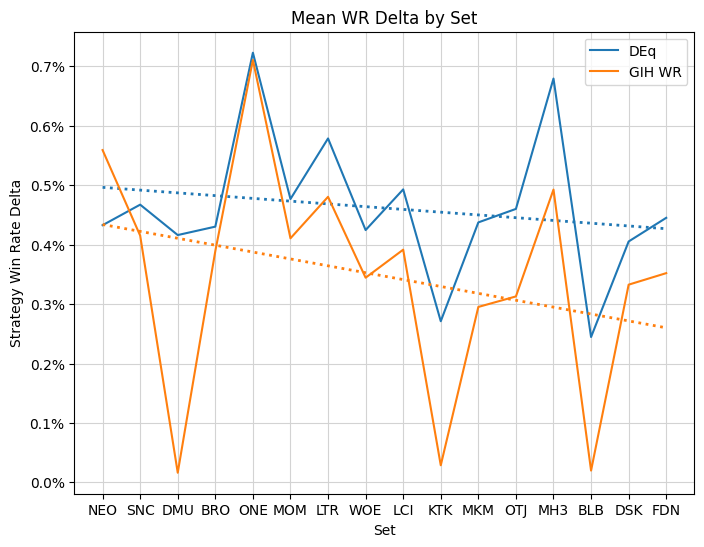

In [2]:
from deq.p1_strategy import set_by_set_results
set_by_set = set_by_set_results()
set_by_set_plot(set_by_set)

As GIH WR has become more ubiquitous, the edge to be gained appears to be decaying, while DEq's has been more stable. I wouldn't bet on it staying that way.

### Changelog

 - 2024-01-26 Initial publication